In [6]:
import numpy as np
import matplotlib.pyplot as plt
#----------parameters---------------
S0 = 80        # Initial stock price
K = 80         # Strike price
T = 1.0         # Time to maturity (in years)
r = 0.05        # Risk-free interest rate
sigma = 0.2     # Volatility of the asset
M = 100         # Number of time steps
N = 10000       # Number of simulations
dt = T / M      # Time step size
discount = np.exp(-r * T)  # Discount factor
np.random.seed(42)         # to reproduce



In [7]:

# Simulate GBM paths using Euler-Maruyama
def simulate_paths():
    paths = np.zeros((N, M + 1))
    paths[:, 0] = S0 #start from initial stock price
    for t in range(1, M + 1):  #M no of timestamps
        Z = np.random.normal(0, 1, N)      # Gaussian random noise
        paths[:, t] = paths[:, t - 1] * (1 + r * dt + sigma * np.sqrt(dt) * Z)
    return paths

In [8]:
# Payoff functions
def european_call(paths):
    return np.maximum(paths[:, -1] - K, 0)      #St = paths[:, -1]

def arithmetic_asian_call(paths):
    average = np.mean(paths[:, 1:], axis=1)  # Exclude S0 for averaging.... St_i
    return np.maximum(average - K, 0)

def geometric_asian_call(paths):
    geo_mean = np.exp(np.mean(np.log(paths[:, 1:]), axis=1))
    return np.maximum(geo_mean - K, 0)

def lookback_floating_strike_call(paths):
    S_max = np.max(paths, axis=1)
    S_min = np.min(paths, axis=1)
    return S_max - paths[:, -1]  # Floating strike: min(S), but reversed here

#     #or
# def lookback_floating_strike_call(paths):
#     S_min = np.min(paths, axis=1)
#     return np.maximum(paths[:, -1] - S_min, 0)


In [9]:
# Main pricing function <MONTE CARLO SIMULATION>
def price_option(payoff_func, name):
    paths = simulate_paths()
    payoff = payoff_func(paths)
    price = discount * np.mean(payoff)
    std_error = discount * np.std(payoff) / np.sqrt(N)
    print(f"{name} Price: {price:.4f} (Std Error: {std_error:.4f})")
    return price, paths


European Call Option Price: 8.1353 (Std Error: 0.1149)
Arithmetic Asian Call Option Price: 4.5775 (Std Error: 0.0631)
Geometric Asian Call Option Price: 4.4969 (Std Error: 0.0621)
Lookback Floating Strike Call Option Price: 10.2874 (Std Error: 0.0783)


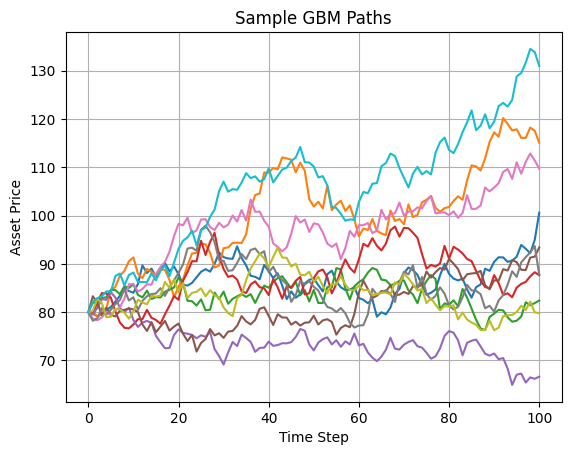

In [10]:
# Price each option
price_option(european_call, "European Call Option")
price_option(arithmetic_asian_call, "Arithmetic Asian Call Option")
price_option(geometric_asian_call, "Geometric Asian Call Option")
price_option(lookback_floating_strike_call, "Lookback Floating Strike Call Option")

# Plot sample paths
sample_paths = simulate_paths()[:10].T
plt.plot(sample_paths)
plt.title("Sample GBM Paths")
plt.xlabel("Time Step")
plt.ylabel("Asset Price")
plt.grid(True)
plt.show()